In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import jax 
import jax.numpy as jnp

from jax.typing import ArrayLike
from typing import NamedTuple

import matplotlib.pyplot as plt

import flax.nnx as nnx

from probjax.nn.nets.transformer import  Transformer, MLP

In [3]:
def random_split_like_tree(rng_key, target=None, treedef=None):
    if treedef is None:
        treedef = jax.tree_structure(target)
    keys = jax.random.split(rng_key, treedef.num_leaves)
    return jax.tree_unflatten(treedef, keys)


def tree_random_normal_like(rng_key, target):
    keys_tree = random_split_like_tree(rng_key, target)
    return jax.tree_map(
        lambda l, k: jax.random.normal(k, l.shape, l.dtype),
        target,
        keys_tree,
    )

In [4]:
from typing import Callable


class FunctionalComponent:
    def __init__(self, id: int, function: Callable):
        self.id = id
        self.function = function

    def __call__(self, mask: ArrayLike,x: ArrayLike):
        def true_fn():
            return self.function(x)
        def false_fn():
            return x
        
        return jax.lax.cond(mask[self.id], true_fn, false_fn)
    
class NormalComponent:
    def __init__(self, id: int, shape: tuple):
        self.id = id
        self.shape = shape

    def __call__(self, mask: ArrayLike, rng, params):
        mu, std = jnp.split(params[self.id],2)
        mu = mu.reshape(self.shape)
        std = std.reshape(self.shape)
        def true_fn():
            return jax.random.normal(rng, self.shape) * jax.nn.softplus(std) + mu
        def false_fn():
            return jnp.zeros(self.shape)
        
        return jax.lax.cond(mask[self.id], true_fn, false_fn)
    

        

In [5]:
NUM_COMPONENTS = 4

random_source = NormalComponent(0, ())
sin_component = FunctionalComponent(1, jnp.sin)
cos_component = FunctionalComponent(2, jnp.cos)
random_noise = NormalComponent(3, ())

NUM_SAMPLES = 500


PARAMS_STRUC = {0: jnp.array([0.,1.]), 3: jnp.array([0.,1.])}

COMPONENT_PARAMETERIZES = [i in PARAMS_STRUC for i in range(NUM_COMPONENTS)]

def prior_params(rng):
    # For now we will keep params fixed
    return tree_random_normal_like(jax.random.PRNGKey(0), PARAMS_STRUC)



def f(component_mask, rng, params_model):
    x = random_source(component_mask, rng, params_model)
    y = sin_component(component_mask, x)
    z = cos_component(component_mask, y)
    eps = random_noise(component_mask, rng, params_model)
    return z + eps


2024-11-01 10:59:29.121250: W external/xla/xla/service/gpu/nvptx_compiler.cc:930] The NVIDIA driver's CUDA version is 12.5 which is older than the PTX compiler version 12.6.77. Because the driver is older than the PTX compiler version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


/tmp/ipykernel_7345/3281511299.py:3: DeprecationWarning: jax.tree_structure is deprecated: use jax.tree.structure (jax v0.4.25 or newer) or jax.tree_util.tree_structure (any JAX version).
  treedef = jax.tree_structure(target)
/tmp/ipykernel_7345/3281511299.py:5: DeprecationWarning: jax.tree_unflatten is deprecated: use jax.tree.unflatten (jax v0.4.25 or newer) or jax.tree_util.tree_unflatten (any JAX version).
  return jax.tree_unflatten(treedef, keys)
/tmp/ipykernel_7345/3281511299.py:10: DeprecationWarning: jax.tree_map is deprecated: use jax.tree.map (jax v0.4.25 or newer) or jax.tree_util.tree_map (any JAX version).
  return jax.tree_map(


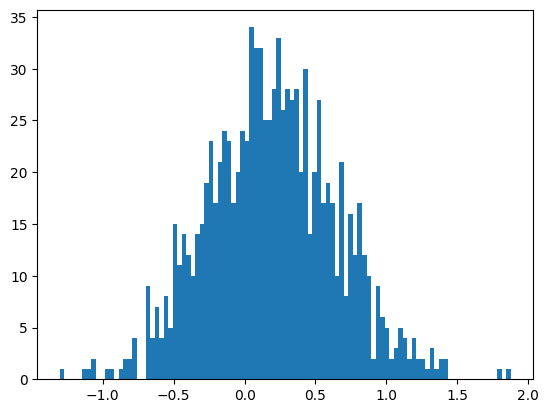

In [6]:
component_mask = jnp.array([False, False, False, True])  

params = prior_params(jax.random.PRNGKey(1))
rng = jax.random.PRNGKey(0)
keys = jax.random.split(rng, 1000)
outputs = jax.vmap(f, in_axes=(0, 0, None))(jnp.stack([component_mask]*1000), keys, params)

_ = plt.hist(outputs.flatten(), bins=100)

In [7]:


def generate_data(rng_key, num_samples=NUM_SAMPLES):
    rng_key_model, rng_key_params, rng_data = jax.random.split(rng_key,3)
    component_mask = jax.random.bernoulli(rng_key_model, p=0.7, shape=(NUM_COMPONENTS,))
    keys = jax.random.split(rng_data, num_samples)
    params = prior_params(rng_key_params)
    outputs = jax.vmap(f, in_axes=[None,0,None])(component_mask, keys, params)


    return component_mask, outputs, params
    

In [29]:
    
class ModelIdentificationDecoder(nnx.Module, experimental_pytree=True):

    model_dim: int = 50
    num_heads: int = 4
    num_layers: int = 2
    widening_factor: int = 2
    attn_size: int = 10

    def __init__(self, dim,context_dim,rngs, dropout_rate=None):
        self.embed = nnx.Embed(2, dim, rngs=rngs)
        self.transformer = Transformer(dim, self.num_heads,self.num_heads,self.attn_size, context_dim=50, widening_factor=self.widening_factor,rngs=rngs, dropout_rate=dropout_rate)
        self.output = nnx.Linear(dim, 1, rngs=rngs)
        self.context_embedding = MLP([context_dim, 2*dim,dim], rngs=rngs)

    def __call__(self, x, context,decode=False, deterministic=False):
        # Autoregressive mask 
        x = self.embed(x.astype(jnp.int32))
        context = self.context_embedding(context)
        start_token = jnp.ones_like(x[...,:1,:])
        x = jnp.concatenate([start_token, x], axis=-2)
        mask = jnp.tril(jnp.ones((x.shape[-2], x.shape[-2])))
        context = context[..., None, :]
        x = self.transformer(x, context=context,mask=mask, deterministic=deterministic, decode=decode)
        logits = self.output(x)
        return logits[..., :-1, 0]

In [30]:
model = ModelIdentificationDecoder(50,500, rngs=nnx.Rngs(0))

In [31]:
# nnx.display(model)

In [32]:
component_mask, data, params = generate_data(jax.random.PRNGKey(1))

/tmp/ipykernel_7345/3281511299.py:3: DeprecationWarning: jax.tree_structure is deprecated: use jax.tree.structure (jax v0.4.25 or newer) or jax.tree_util.tree_structure (any JAX version).
  treedef = jax.tree_structure(target)
/tmp/ipykernel_7345/3281511299.py:5: DeprecationWarning: jax.tree_unflatten is deprecated: use jax.tree.unflatten (jax v0.4.25 or newer) or jax.tree_util.tree_unflatten (any JAX version).
  return jax.tree_unflatten(treedef, keys)
/tmp/ipykernel_7345/3281511299.py:10: DeprecationWarning: jax.tree_map is deprecated: use jax.tree.map (jax v0.4.25 or newer) or jax.tree_util.tree_map (any JAX version).
  return jax.tree_map(


In [33]:
model(component_mask, data)

Array([-0.671,  1.081, -2.072, -2.043], dtype=float32)

In [34]:
import optax


optimizer = optax.adam(1e-4)




def loss_fn(params,model, key):
    nnx.update(model, params)

    keys = jax.random.split(key, (1024,))
    component_mask, data, _ = jax.vmap(generate_data)(keys)

    logits = model(component_mask, data)
    loss = jnp.mean(optax.sigmoid_binary_cross_entropy(logits, component_mask))
    return loss


@jax.jit
def update(params,model, key, opt_state):
    loss, grads = jax.value_and_grad(loss_fn)(params,model, key)
    updates, opt_state = optimizer.update(grads, opt_state)
    params = optax.apply_updates(params, updates)
    return loss, params, opt_state

In [35]:
params = nnx.state(model, nnx.Param)
key = jax.random.PRNGKey(0)
opt_state = optimizer.init(params)    

In [36]:
loss_fn(params,model, key)

/tmp/ipykernel_7345/3281511299.py:3: DeprecationWarning: jax.tree_structure is deprecated: use jax.tree.structure (jax v0.4.25 or newer) or jax.tree_util.tree_structure (any JAX version).
  treedef = jax.tree_structure(target)
/tmp/ipykernel_7345/3281511299.py:5: DeprecationWarning: jax.tree_unflatten is deprecated: use jax.tree.unflatten (jax v0.4.25 or newer) or jax.tree_util.tree_unflatten (any JAX version).
  return jax.tree_unflatten(treedef, keys)
/tmp/ipykernel_7345/3281511299.py:10: DeprecationWarning: jax.tree_map is deprecated: use jax.tree.map (jax v0.4.25 or newer) or jax.tree_util.tree_map (any JAX version).
  return jax.tree_map(


Array(1.097, dtype=float32)

In [37]:

for i in range(5_000):
    key, subkey, key2 = jax.random.split(key, 3)
    loss, params, opt_state = update(params,model,subkey, opt_state)
    if (i % 500) == 0:
        print(loss)

/tmp/ipykernel_7345/3281511299.py:3: DeprecationWarning: jax.tree_structure is deprecated: use jax.tree.structure (jax v0.4.25 or newer) or jax.tree_util.tree_structure (any JAX version).
  treedef = jax.tree_structure(target)
/tmp/ipykernel_7345/3281511299.py:5: DeprecationWarning: jax.tree_unflatten is deprecated: use jax.tree.unflatten (jax v0.4.25 or newer) or jax.tree_util.tree_unflatten (any JAX version).
  return jax.tree_unflatten(treedef, keys)
/tmp/ipykernel_7345/3281511299.py:10: DeprecationWarning: jax.tree_map is deprecated: use jax.tree.map (jax v0.4.25 or newer) or jax.tree_util.tree_map (any JAX version).
  return jax.tree_map(


1.0722799
0.3705756
0.27893996
0.25248858
0.25261217
0.23587401
0.20670894
0.18804497
0.17854609
0.17700344


In [38]:
nnx.update(model, params)

In [50]:

def naive_autoregressive_decoding(key, context, T=4):
    x = jnp.zeros((T,), dtype=jnp.bool_)
    def scan_fn(carry, k):
        x, i = carry
        logits = model(x.astype(jnp.int32), context)
        print(logits.shape)
        p_i = jax.nn.sigmoid(logits[i])
        
        x_i = jax.random.bernoulli(k, p_i)
        x = x.at[i].set(x_i)
        return (x, i+1), None
    keys = jax.random.split(key, (T,))
    x, _ = jax.lax.scan(scan_fn, (x, 0), keys)
    
    return x[0]

In [70]:
true_mask, data, _  = generate_data(jax.random.PRNGKey(2))
logits = model(true_mask, data)
probs = jax.nn.sigmoid(logits)
probs

/tmp/ipykernel_7345/3281511299.py:3: DeprecationWarning: jax.tree_structure is deprecated: use jax.tree.structure (jax v0.4.25 or newer) or jax.tree_util.tree_structure (any JAX version).
  treedef = jax.tree_structure(target)
/tmp/ipykernel_7345/3281511299.py:5: DeprecationWarning: jax.tree_unflatten is deprecated: use jax.tree.unflatten (jax v0.4.25 or newer) or jax.tree_util.tree_unflatten (any JAX version).
  return jax.tree_unflatten(treedef, keys)
/tmp/ipykernel_7345/3281511299.py:10: DeprecationWarning: jax.tree_map is deprecated: use jax.tree.map (jax v0.4.25 or newer) or jax.tree_util.tree_map (any JAX version).
  return jax.tree_map(


Array([1.   , 0.788, 0.   , 0.999], dtype=float32)

In [71]:
true_mask

Array([ True,  True, False,  True], dtype=bool)

In [92]:
keys = jax.random.split(jax.random.PRNGKey(10), 10)
samples_mask = jax.vmap(naive_autoregressive_decoding, in_axes=(0,None))(keys, data)

(4,)


In [93]:
samples_mask

Array([[ True,  True, False,  True],
       [ True,  True, False,  True],
       [ True, False, False,  True],
       [ True,  True, False,  True],
       [ True,  True, False,  True],
       [ True, False, False,  True],
       [ True,  True, False,  True],
       [ True,  True, False,  True],
       [ True,  True, False,  True],
       [ True,  True, False,  True]], dtype=bool)

In [98]:

x_pred = jax.vmap(lambda key : f(samples_mask[0], key, prior_params(key)))(jax.random.split(jax.random.PRNGKey(0), 500))

/tmp/ipykernel_7345/3281511299.py:3: DeprecationWarning: jax.tree_structure is deprecated: use jax.tree.structure (jax v0.4.25 or newer) or jax.tree_util.tree_structure (any JAX version).
  treedef = jax.tree_structure(target)
/tmp/ipykernel_7345/3281511299.py:5: DeprecationWarning: jax.tree_unflatten is deprecated: use jax.tree.unflatten (jax v0.4.25 or newer) or jax.tree_util.tree_unflatten (any JAX version).
  return jax.tree_unflatten(treedef, keys)
/tmp/ipykernel_7345/3281511299.py:10: DeprecationWarning: jax.tree_map is deprecated: use jax.tree.map (jax v0.4.25 or newer) or jax.tree_util.tree_map (any JAX version).
  return jax.tree_map(


(array([ 1.,  0.,  0.,  0.,  1.,  1.,  1.,  0.,  1.,  0.,  2.,  0.,  2.,
         3.,  4.,  2.,  5.,  6.,  6.,  3.,  6.,  7.,  2.,  5., 11.,  2.,
         9.,  5.,  4.,  8., 14., 16., 10.,  9.,  9.,  6.,  9.,  8.,  9.,
        15., 11., 13., 11.,  9., 13., 12.,  9., 15., 12.,  6., 15., 10.,
         7.,  8., 10.,  8., 11.,  6.,  7.,  4.,  5.,  6.,  9.,  8.,  7.,
         5.,  2.,  5.,  6.,  3.,  8.,  3.,  6.,  5.,  2.,  6.,  3.,  1.,
         2.,  1.,  1.,  2.,  1.,  1.,  0.,  1.,  0.,  0.,  0.,  1.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.]),
 array([-2.047, -1.998, -1.949, -1.9  , -1.851, -1.803, -1.754, -1.705,
        -1.656, -1.607, -1.559, -1.51 , -1.461, -1.412, -1.364, -1.315,
        -1.266, -1.217, -1.168, -1.12 , -1.071, -1.022, -0.973, -0.924,
        -0.876, -0.827, -0.778, -0.729, -0.681, -0.632, -0.583, -0.534,
        -0.485, -0.437, -0.388, -0.339, -0.29 , -0.241, -0.193, -0.144,
        -0.095, -0.046,  0.003,  0.051,  0.1  ,  0.149,  0.198,  0.246,
  

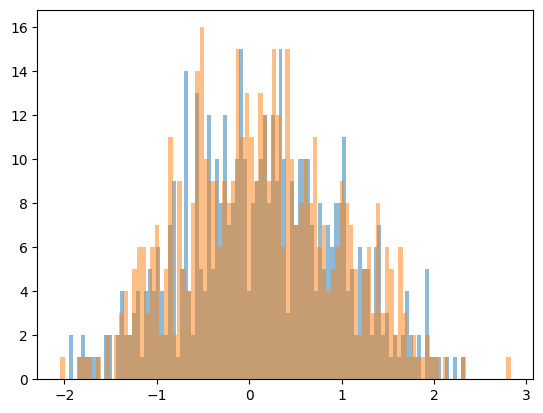

In [99]:
plt.hist(x_pred.flatten(), bins=100, alpha=0.5)
plt.hist(data.flatten(), bins=100, alpha=0.5)

In [ ]:
input[0]

Array([ True, False,  True,  True], dtype=bool)

In [ ]:
params_model

[Array([[ 0.001, -0.034]], dtype=float32),
 Array([[ 0.339, -0.   ]], dtype=float32)]

In [ ]:
input[0]

Array([ True, False,  True,  True], dtype=bool)

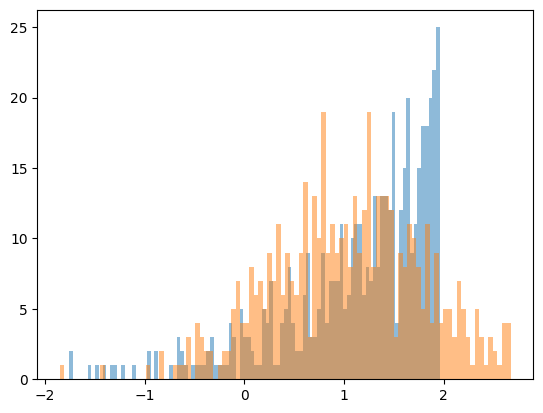

In [ ]:
_ = plt.hist(x_pred.flatten(), bins=100, alpha=0.5)
_ = plt.hist(input[1].flatten(), alpha=0.5, bins=100)

In [ ]:
input[2]

{0: Array([ 1.848, -0.301], dtype=float32),
 3: Array([-0.788, -1.355], dtype=float32)}